# 5n-DC Analysis

In [1]:
# import
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import MDAnalysis as mda
import xarray as arr
import mdtraj as md
import scipy
from MDAnalysis.analysis import distances

In [2]:
# paths to simulations
path1 = "/data/geissler/simulations/rec_lig/5n-dc/1rep/"  # path to replica1
path2 = "/data/geissler/simulations/rec_lig/5n-dc/2rep/"  # path to replica2
path3 = "/data/geissler/simulations/rec_lig/5n-dc/3rep/"  # path to replica3
path_combined = "/data/geissler/simulations/rec_lig/5n-dc/combined/"  # path to folder with concatenated version of all 3 replicas
path_stats = "/data/geissler/simulations/rec_lig/5n-dc/combined/stats/"  # path to save results

## Distance Calcium and Ligand to pocket

In [3]:
# all three replica concatenated, trajectory centered on pocket residues
traj = mda.Universe(path_combined+'md_500ns.pdb',
                   path_combined+'pocket_centered.xtc')

In [4]:
# this calculates the distance between pocket calcium atom and the Center of Mass of the binding pocket
cal = traj.select_atoms('resname CAL and resid 386')  # pocket calcium
pocket = traj.select_atoms('protein and (resid 347 or resid 349 or resid 354 or resid 365)') # pocket defining residues 

cal_pocket = []
R = np.zeros((cal.atoms.n_atoms, cal.atoms.n_atoms))  # just one atom/position per frame

for ts in traj.trajectory:
    pocket_com = pocket.center_of_geometry()  # calculates center of mass
    dist_arr = distances.distance_array(cal.positions,
                                       pocket_com,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    cal_pocket.append(dist_arr/10)  # convert from Angstr. to nm
cal_pocket_flat = np.concatenate([d.flatten() for d in cal_pocket])

In [5]:
# this calculates the distance between center of mass of mannose and the Center of Mass of the binding pocket
mannose = traj.select_atoms('resname LIG and (name C1 or name C2 or name C3 or name C4 or name C5 or name O5)')  # mannose ring atoms
pocket = traj.select_atoms('protein and (resid 347 or resid 349 or resid 354 or resid 365)')  # pocket defining residues 

lig_pocket = []
R = np.zeros((cal.atoms.n_atoms, cal.atoms.n_atoms))  # just one atom/position per frame

for ts in traj.trajectory:
    man_com = mannose.center_of_geometry() # 
    pocket_com = pocket.center_of_geometry()  # calculates center of mass
    dist_arr = distances.distance_array(man_com,
                                       pocket_com,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    lig_pocket.append(dist_arr/10)  # convert from Angstr. to nm

lig_pocket_flat = np.concatenate([d.flatten() for d in lig_pocket])

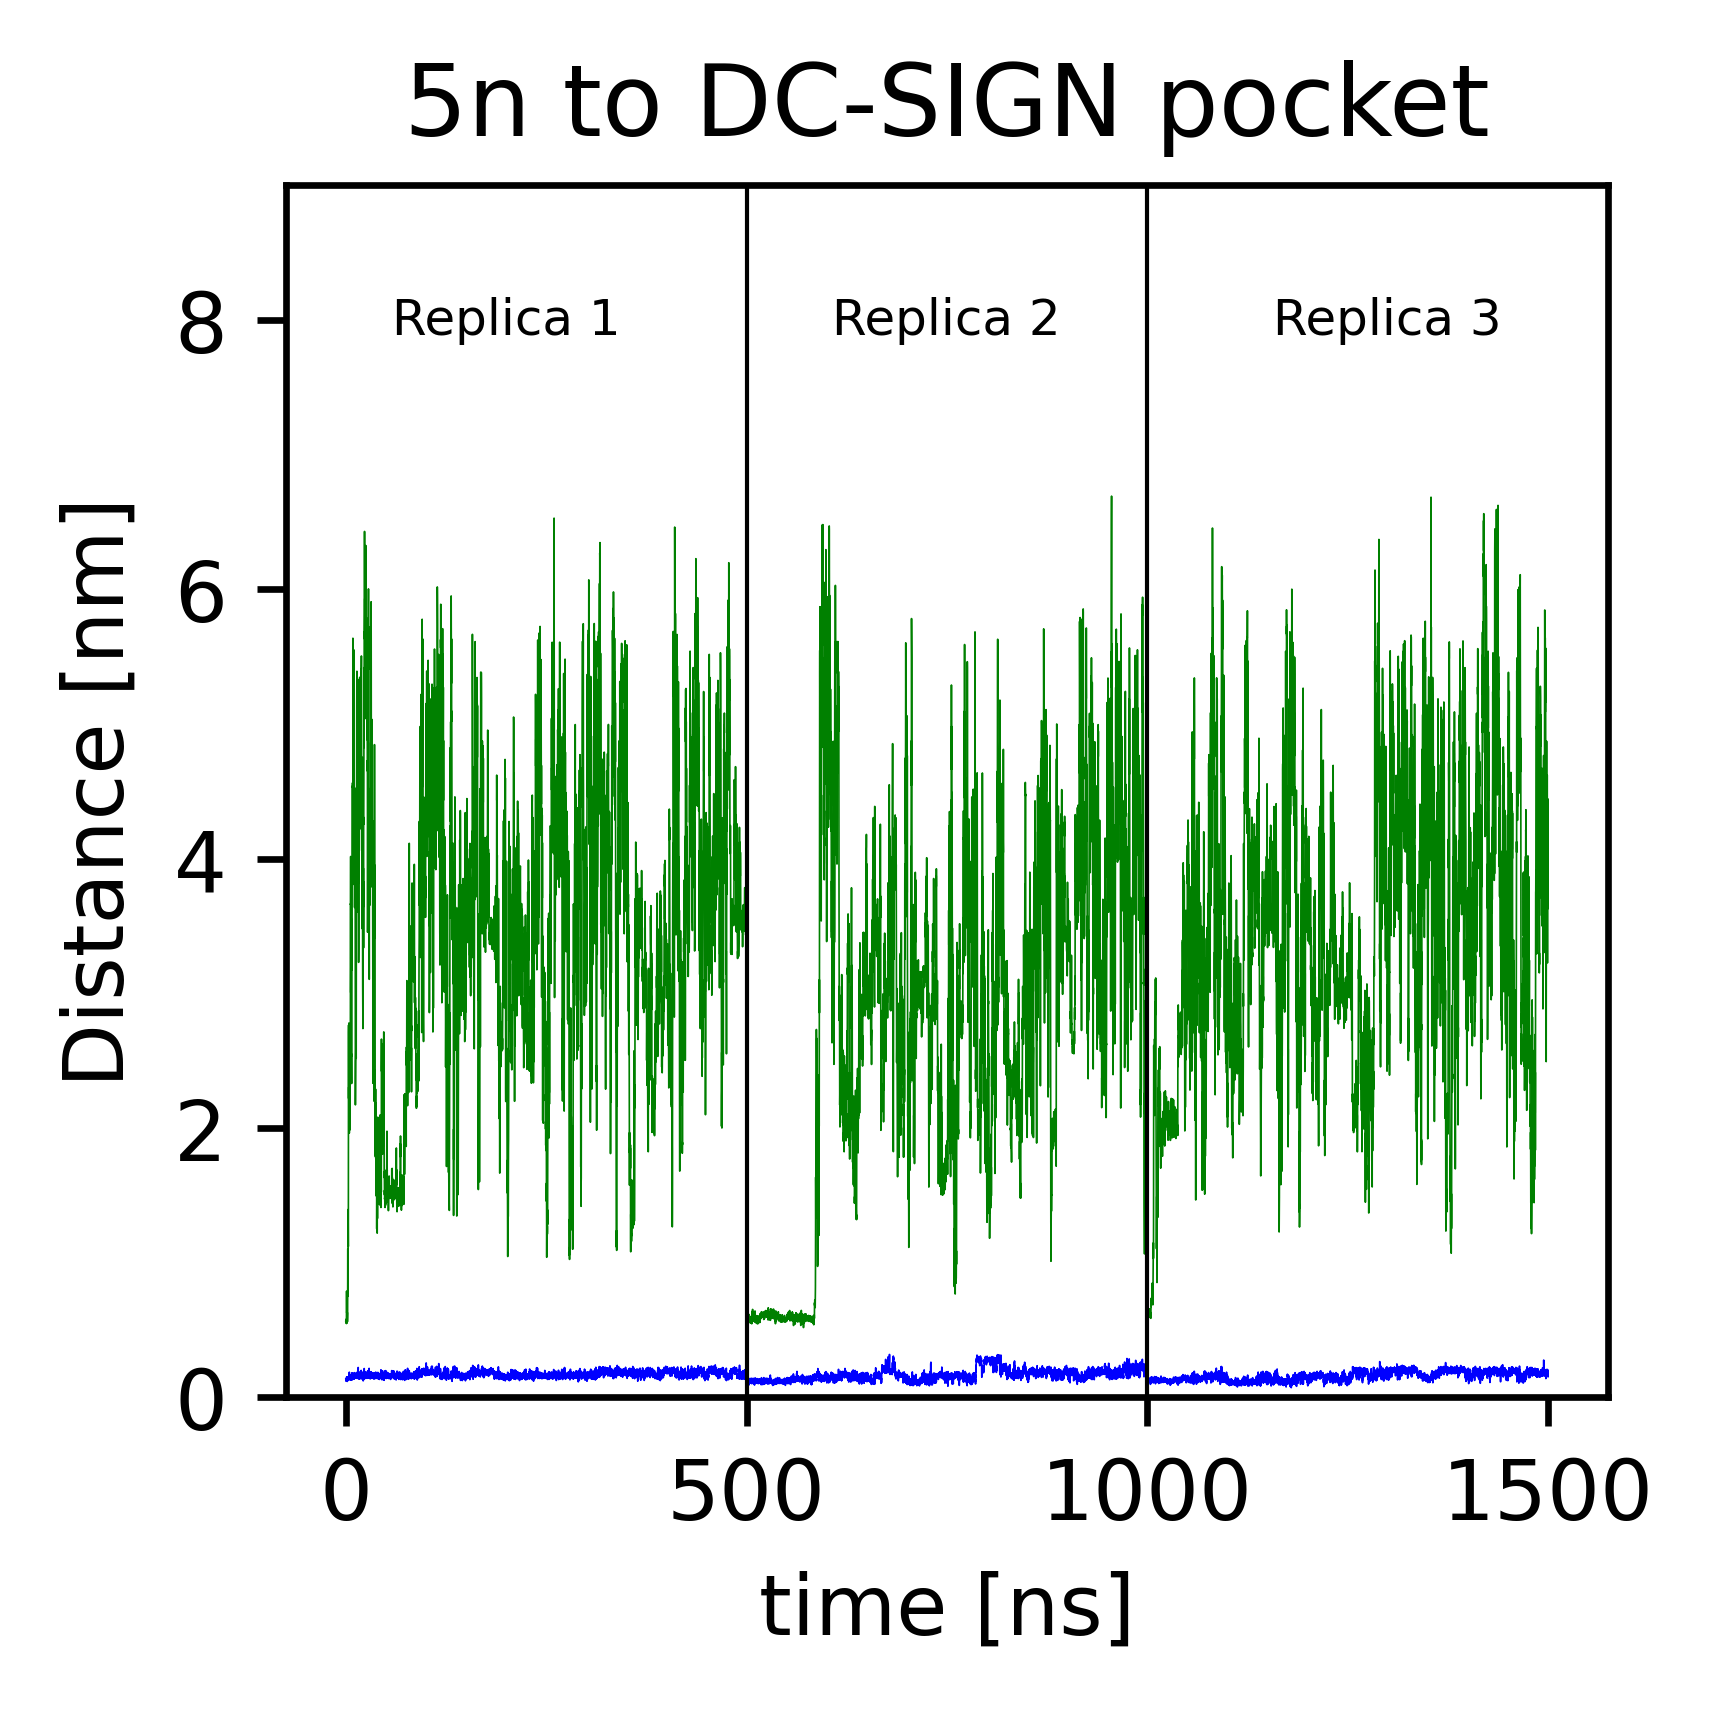

In [6]:
# plot Distances

cm = 1/2.54
fig, ax = plt.subplots(figsize=(7.5*cm, 7.5*cm), dpi=600)

ax.plot(cal_pocket_flat, linewidth=0.2, c='#0000FF', alpha=1)  # RMSD Cal
ax.plot(lig_pocket_flat, linewidth=0.2, c='green', alpha=1)  # RMSD lig
plt.axvline(5000, color='#000000', linewidth=0.5)  # borders between replica
plt.axvline(10000, color='#000000', linewidth=0.5)

plt.text(2000, 8, "Replica 1", size=6, rotation=0.,  # labels
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(7500, 8, "Replica 2", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(13000, 8, "Replica 3", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))

ax.set_ylim(0,9)
# ax.set_xlim(0,15010)
plt.xticks([0, 5000, 10000, 15000,], ['0', '500', '1000', '1500',], fontsize=10)
plt.title('5n to DC-SIGN pocket')
ax.set_xlabel('time [ns]')
ax.set_ylabel('Distance [nm]')
plt.tight_layout()
plt.savefig("/data/geissler/analysis/paper1_scripts_reproducability/distance_plots/5n-dc.png")

## RMSD Calcium and Ligand to pocket

### Cal to pocket

RMSD was calculated with gromacs using the protein backbone as the group for least squares fit and the Calcium atom for the RMSD calculation. The trajectory was centered on the pocket atoms, otherwise the calcium atoms jumps in and out of the box.

In [22]:
# load data
rmsd_cal_center = np.loadtxt(f"{path_stats}cal_center_rmsd.xvg",
                     comments =['#','@'])
rmsd_cal_center[:, 0] = np.arange(0, 15003)
rmsd_lig = np.loadtxt(f"{path_stats}rmsd_lig.xvg",
                     comments =['#','@'])
rmsd_lig[:, 0] = np.arange(0, 15003)

In [23]:
# smooth RMSD over 20 frames
def movingaverage(values, window):
    weights = np.repeat(1.0, window)/window
    sma = np.convolve(values, weights, 'valid')
    return sma
av = 20

In [24]:
rmean_cal = movingaverage(rmsd_cal_center[:,1], av)
rmean_lig = movingaverage(rmsd_lig[:,1], av)

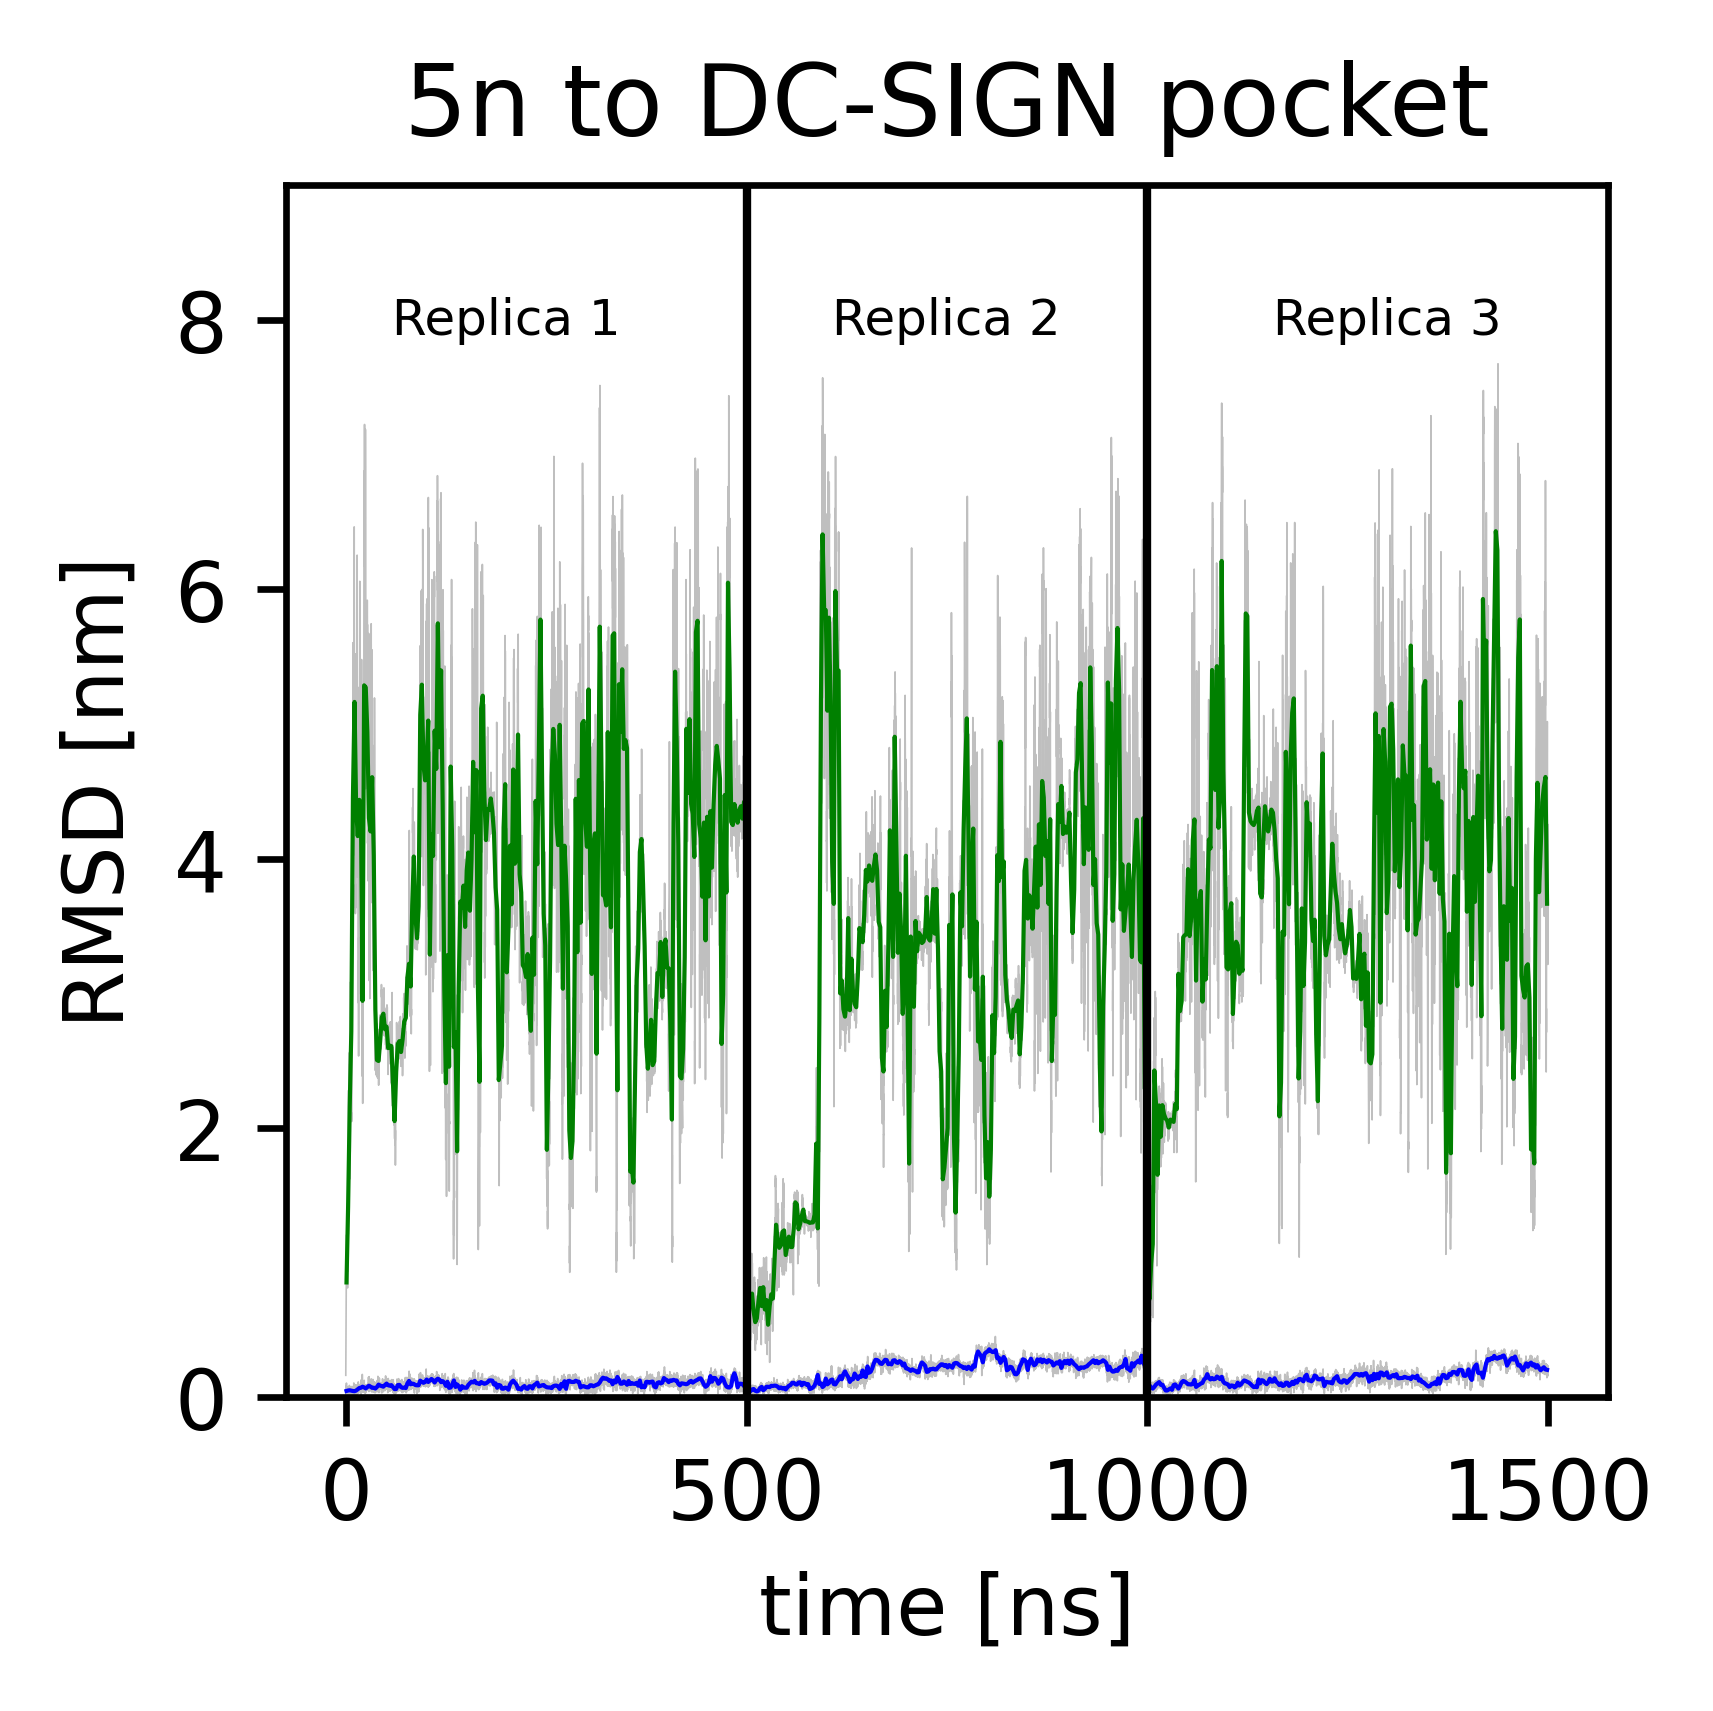

In [26]:
# plot RMSD
cm = 1/2.54
fig, ax = plt.subplots(figsize=(7.5*cm, 7.5*cm), dpi=600)

ax.plot(rmsd_cal_center.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD Cal
ax.plot(rmsd_cal_center[int(av/2-1):-int(av/2),0][::av]/1, rmean_cal[::av], linewidth=0.5, c='#0000FF') # smoothed RMSD Cal
ax.plot(rmsd_lig.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD lig
ax.plot(rmsd_lig[int(av/2-1):-int(av/2),0][::av]/1, rmean_lig[::av], linewidth=0.5, c='green') # smoothed RMSD lig
plt.axvline(5000, color='#000000', linewidth=1)  # borders between replica
plt.axvline(10000, color='#000000', linewidth=1)

plt.text(2000, 8, "Replica 1", size=6, rotation=0.,  # labels
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(7500, 8, "Replica 2", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(13000, 8, "Replica 3", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))

ax.set_ylim(0,9)
# ax.set_xlim(0,15010)
plt.xticks([0, 5000, 10000, 15000,], ['0', '500', '1000', '1500',], fontsize=10)
plt.title('5n to DC-SIGN pocket')
ax.set_xlabel('time [ns]')
ax.set_ylabel('RMSD [nm]')
plt.tight_layout()
plt.savefig("/data/geissler/analysis/RMSD/cal_lig/5n-dc.png")

## different binding states 

Here I define the different binding conformations ("binding states") by distances of different mannose Hydroxy-groups to different amino acids in the binding pocket of the receptor: 
<br> 
(the different HO-groups are hightlighted in Fig.5 of the paper)
- the "crystal state" is defined by HO4 being close to Glu347, HO3 being close to Glu354, HO6 being far away from Glu358 and HO2 being far away from Glu347
- "state A" is defined by HO2 being close to Glu347, HO4 being far from Glu347, HO6 being far from Glu358 and HO2 being far from Glu354
- "state B" is defined by HO2 being close to Glu354, HO4 being far from Glu347, HO6 being far from Glu358 and HO2 being far from Glu347
- "state C" is defined by HO6 being close to Glu358, HO3 being close to Glu354 and HO2 being far from Glu347 

In [3]:
# for the calculations I concatenated all frames of ligand being bound to the pocket
traj = mda.Universe(path_combined+'md_500ns.pdb',
                   path_combined+'combined_bound.xtc')

As I define the binding states by distances, I calculate the different distances between HO atoms and the respective amino acids

In [4]:
# this calculates the distance between the two defined atoms below for each frame of the simulation and appends them to a list
# distance 1: HO6 to Glutamic Acid 358
man = traj.select_atoms('resname LIG and name HO6')
prot = traj.select_atoms('protein and resid 358 and name CD') 

distance1 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance1.append(dist_arr/10)  # convert from Angstr. to nm

In [5]:
# distance 2: HO2 to Glutamic Acid 347
man = traj.select_atoms('resname LIG and name HO2')
prot = traj.select_atoms('protein and resid 347 and name CD')

distance2 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance2.append(dist_arr/10)  # convert from Angstr. to nm

In [6]:
# distance 3: HO3 to Glutamic Acid 354
man = traj.select_atoms('resname LIG and name HO3')
prot = traj.select_atoms('protein and resid 354 and name CD')

distance3 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance3.append(dist_arr/10)  # convert from Angstr. to nm

In [7]:
# distance 4: HO4 to Glutamic Acid 347 
man = traj.select_atoms('resname LIG and name HO4')
prot = traj.select_atoms('protein and resid 347 and name CD')

distance4 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance4.append(dist_arr/10)  # convert from Angstr. to nm

In [8]:
# distance 5: HO2 to Glutamic Acid 354
man = traj.select_atoms('resname LIG and name HO2')  
prot = traj.select_atoms('protein and resid 354 and name CD')

distance5 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance5.append(dist_arr/10)  # convert from Angstr. to nm

In [9]:
# now I put them into 1 array
all_distances=np.column_stack((distance1,distance2,distance3,distance4,distance5))
# and make it flat
distances_flat=all_distances[:,:,0]
np.save(f"{path_stats}distances_flat.npy", distances_flat)

Now I sort the frames into their respective state. I defined the cutoff between close and far at 3.5 Ångström which roughliy corresponds to the length of a hydrogen bond.

In [10]:
# crystal state: HO4 close to Glu725, HO3 close to Glu733, HO6 far away from Glu737 and HO2 far away from Glu725
crystal = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][3] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        crystal.append(i)
print(len(crystal))  # print how many frames correspond to the crystal state

273


In [11]:
# state A: HO2 close to Glu725, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu733
stateA = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][1] <= 0.35 and distances_flat[i][3] > 0.35 and  distances_flat[i][0] > 0.35 and distances_flat[i][4] > 0.35:
        stateA.append(i)
print(len(stateA))

450


In [12]:
# state B: HO2 close to Glu733, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu725
stateB = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][4] <= 0.35 and distances_flat[i][3] > 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        stateB.append(i)
print(len(stateB))

31


In [13]:
# state C: HO6 close to Glu737, HO3 close to Glu733 and HO2 far from Glu725
stateC = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][0] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][1] > 0.35:
        stateC.append(i)
print(len(stateC))

0


In [14]:
# this is how I find out how many frames do not fall into any defined state ("others")
len(distances_flat)-len(crystal)-len(stateA)-len(stateB)-len(stateC)

209

## get frames of specific states to make a trajectory

For mmPBSA calculation for the specific states and for producing state contact maps, I will bin the frames of the same state together into one state specific trajectory. 
<br>
However I will only do that if I get more than 100 frames for the state.
<br>
By multiplying the frame numbers with 100 ps and considering the order of replicas, I can use the output below directly as input for the 'states_trajectory.sh' bash script.

This is what the combined bound traj is made of:

- 1rep bound:  21 frames,  2 ns,  2100 ps
- 2rep bound: 871 frames, 87 ns, 87100 ps
- 3rep bound:  71 frames,  7 ns,  7100 ps

  963 frames in total -> 96300 ps

### crystal state 

In [16]:
ps = 100 # convert frames into pico seconds 
crystal_ps= [x*ps for x in crystal[:300]] 
print(*crystal_ps)

0 100 200 300 400 500 600 700 800 1100 1200 1300 1400 1500 1600 2100 2200 2300 2400 2500 2600 2700 2800 2900 3000 3100 3200 3300 3400 3500 3600 3700 3800 3900 4000 4100 4200 4300 4400 4500 4600 4700 4800 4900 5000 5100 5200 5300 5400 5500 5600 5700 5800 5900 6000 6100 6200 6300 6400 6500 6600 6700 6800 6900 7000 7100 7200 7300 7400 7500 7600 7700 7800 7900 8000 8100 8200 8300 8400 8500 8600 8700 8800 8900 9000 9200 9300 9400 9500 9700 10000 10300 10400 10500 10700 10800 11100 11200 11300 11400 12000 12200 12600 12700 12800 12900 13000 13100 13200 13300 13400 13500 13600 13700 13800 13900 14000 14100 14200 14300 14400 14500 14600 14700 14800 14900 15000 15100 15200 15300 15400 15500 15600 15700 15800 15900 16000 16100 16200 16300 16400 16500 16600 16700 16800 16900 17000 17100 17200 17300 17400 17500 17600 17700 17800 17900 18000 18100 18200 18300 18400 18500 18600 18700 18800 18900 28300 28700 28800 28900 29000 30800 31100 31300 31700 31800 32000 32100 32200 32300 32400 32500 32900 330

In [17]:
# which frames are in replica 1?
print('frames in 1rep:')
for i in crystal_ps:
    if i <= 2100:
        print(i)

frames in 1rep:
0
100
200
300
400
500
600
700
800
1100
1200
1300
1400
1500
1600
2100


In [18]:
# which frames are in replica 2?
print('frames in 2rep:')
for i in crystal_ps:
    if i > 2100 and i <= (2100+87100):
        print(i-2100)

frames in 2rep:
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7100
7200
7300
7400
7600
7900
8200
8300
8400
8600
8700
9000
9100
9200
9300
9900
10100
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
26200
26600
26700
26800
26900
28700
29000
29200
29600
29700
29900
30000
30100
30200
30300
30400
30800
30900
31000
31100
31200
31300
31400
31600
31700
31800
31900
32000
32100
3220

### state A 

In [19]:
ps = 100 # convert frames into pico seconds 
stateA_ps= [x*ps for x in stateA[:300]] 
print(*stateA_ps)

41900 42000 42200 42300 42400 42500 42600 42700 42800 42900 43000 43100 43200 43300 43400 43500 43600 43700 43800 43900 44000 44100 44200 44300 44400 44500 44600 44700 44800 44900 45000 45100 45200 45300 45400 45500 45600 45700 45800 45900 46000 46100 46200 46300 46400 46500 46700 46800 46900 47000 47100 47200 47300 47400 47500 47600 47700 47800 47900 48000 48100 48200 48300 48400 48500 48600 48700 48800 48900 49000 49100 49200 49300 49500 49600 49700 49800 49900 50000 50100 50200 50300 50400 50500 50600 50700 50800 50900 51000 51100 51200 51300 51400 51500 51600 51800 51900 52000 52100 52200 52300 52400 52500 52600 52700 52800 52900 53000 53200 53300 53400 53500 53600 53700 53800 53900 54000 54100 54200 54300 54400 54500 54600 54700 54800 54900 55000 55100 55200 55300 55400 55500 55600 55700 55800 55900 56000 56100 56200 56300 56400 56500 56600 56700 56800 56900 57000 57100 57200 57300 57400 57500 57600 57700 57800 57900 58000 58100 58200 58300 58400 58500 58600 58700 58800 59000 5910

In [20]:
# which frames are in replica 1?
print('frames in 1rep:')
for i in stateA_ps:
    if i <= 2100:
        print(i)

frames in 1rep:


In [21]:
# which frames are in replica 2?
print('frames in 2rep:')
for i in stateA_ps:
    if i > 2100 and i <= (2100+87100):
        print(i-2100)

frames in 2rep:
39800
39900
40100
40200
40300
40400
40500
40600
40700
40800
40900
41000
41100
41200
41300
41400
41500
41600
41700
41800
41900
42000
42100
42200
42300
42400
42500
42600
42700
42800
42900
43000
43100
43200
43300
43400
43500
43600
43700
43800
43900
44000
44100
44200
44300
44400
44600
44700
44800
44900
45000
45100
45200
45300
45400
45500
45600
45700
45800
45900
46000
46100
46200
46300
46400
46500
46600
46700
46800
46900
47000
47100
47200
47400
47500
47600
47700
47800
47900
48000
48100
48200
48300
48400
48500
48600
48700
48800
48900
49000
49100
49200
49300
49400
49500
49700
49800
49900
50000
50100
50200
50300
50400
50500
50600
50700
50800
50900
51100
51200
51300
51400
51500
51600
51700
51800
51900
52000
52100
52200
52300
52400
52500
52600
52700
52800
52900
53000
53100
53200
53300
53400
53500
53600
53700
53800
53900
54000
54100
54200
54300
54400
54500
54600
54700
54800
54900
55000
55100
55200
55300
55400
55500
55600
55700
55800
55900
56000
56100
56200
56300
56400
56500
56600


### state B has less than 100 frames